# Практическая работа № 5. Классификатор и анализ метрик

**Уровень B. Подбор порога классификации с учётом цены ошибки**

Датасет: IBM Telco Customer Churn. Цель — предсказать уход клиента телеком-компании.

## Постановка задачи и цена ошибок

Положительный класс — уход клиента (`Churn = 1`).

- **FN:** модель считает, что клиент останется, хотя он уходит. Компания не применяет меры удержания и теряет будущую прибыль.
- **FP:** модель считает, что клиент уйдёт, хотя он останется. Компания напрасно предлагает скидку или бонус.

В работе принято, что потеря клиента в 5 раз дороже лишнего удерживающего предложения: `cost(FN) = 5`, `cost(FP) = 1`. Поэтому при выборе порога минимизируется `5 × FN + FP`, а основной метрикой является **recall**. Precision и F1 контролируются, чтобы модель не создавала слишком много ложных тревог.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DATA_PATH = Path('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print('Размер датасета:', df.shape)
print('Пропуски в TotalCharges:', df['TotalCharges'].isna().sum())
display(df.head())

Размер датасета: (7043, 21)
Пропуски в TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


,Количество,"Доля, %"
Остался,5174,73.5
Ушёл,1869,26.5


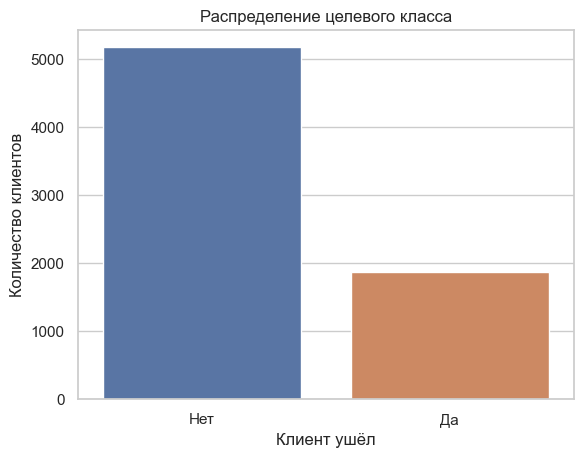

In [3]:
class_table = pd.DataFrame({
    'Количество': df['Churn'].value_counts().sort_index(),
    'Доля, %': (df['Churn'].value_counts(normalize=True).sort_index() * 100).round(1)
})
class_table.index = ['Остался', 'Ушёл']
display(class_table)

ax = sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#DD8452'])
ax.set(title='Распределение целевого класса', xlabel='Клиент ушёл', ylabel='Количество клиентов')
ax.set_xticklabels(['Нет', 'Да'])
plt.show()

## Подготовка данных и обучение

`customerID` удаляется как идентификатор. Данные делятся стратифицированно: 60% на обучение, 20% на подбор порога и 20% на финальное тестирование. Числовые признаки заполняются медианой и масштабируются, категориальные — заполняются модой и кодируются One-Hot Encoding. Все преобразования входят в единый pipeline.

In [4]:
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)
print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)

Train: (4225, 19) Validation: (1409, 19) Test: (1409, 19)


## Вероятности, ROC-кривая и PR-кривая

Модель возвращает вероятность ухода через `predict_proba`. ROC-AUC показывает способность ранжировать случайно выбранного ушедшего клиента выше оставшегося по риску ухода. PR-AUC особенно полезна при дисбалансе, потому что отражает компромисс между precision и recall для положительного класса.

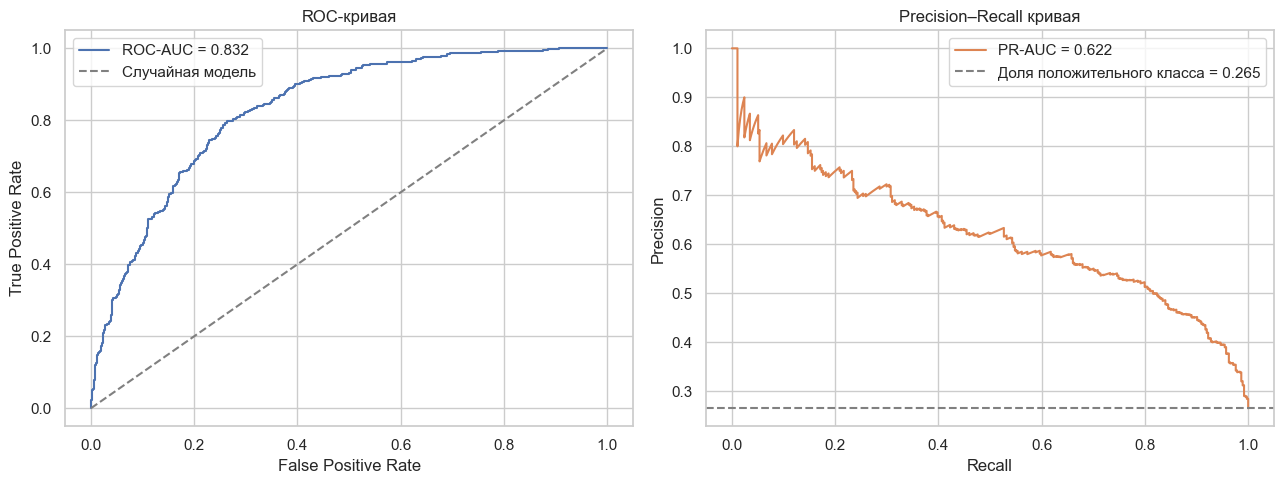

ROC-AUC: 0.832
PR-AUC:  0.622


In [5]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}', color='#4C72B0')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Случайная модель')
axes[0].set(title='ROC-кривая', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend()

axes[1].plot(pr_recall, pr_precision, label=f'PR-AUC = {pr_auc:.3f}', color='#DD8452')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Доля положительного класса = {y_test.mean():.3f}')
axes[1].set(title='Precision–Recall кривая', xlabel='Recall', ylabel='Precision')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'ROC-AUC: {roc_auc:.3f}')
print(f'PR-AUC:  {pr_auc:.3f}')

## Подбор порога на validation

Порог выбирается не на тестовой выборке, а на validation. Проверяются значения от 0,05 до 0,95. Оптимальным считается порог с минимальной стоимостью `5 × FN + FP`.

,threshold,cost,precision,recall,f1,fp,fn
12,0.17,571,0.445,0.925,0.601,431,28
11,0.16,575,0.439,0.930,0.596,445,26
13,0.18,576,0.451,0.914,0.604,416,32
14,0.19,576,0.460,0.904,0.610,396,36
9,0.14,579,0.429,0.941,0.589,469,22
15,0.20,585,0.467,0.890,0.613,380,41
10,0.15,587,0.430,0.933,0.589,462,25
8,0.13,593,0.420,0.944,0.581,488,21
21,0.26,593,0.517,0.840,0.640,293,60
20,0.25,597,0.507,0.845,0.634,307,58


Выбранный порог: 0.17
Минимальная стоимость на validation: 571


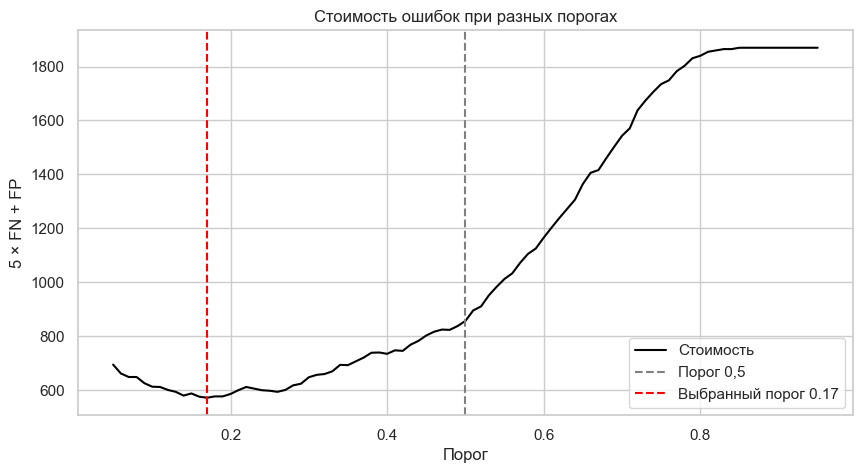

In [6]:
thresholds = np.arange(0.05, 0.951, 0.01)
rows = []
for threshold in thresholds:
    pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    rows.append({
        'threshold': threshold, 'cost': 5 * fn + fp,
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'fp': fp, 'fn': fn
    })
threshold_results = pd.DataFrame(rows)
best_row = threshold_results.loc[threshold_results['cost'].idxmin()]
best_threshold = float(best_row['threshold'])

display(threshold_results.sort_values(['cost', 'threshold']).head(10).round(3))
print(f'Выбранный порог: {best_threshold:.2f}')
print(f'Минимальная стоимость на validation: {best_row["cost"]:.0f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_results['threshold'], threshold_results['cost'], color='black', label='Стоимость')
ax1.axvline(0.5, linestyle='--', color='gray', label='Порог 0,5')
ax1.axvline(best_threshold, linestyle='--', color='red', label=f'Выбранный порог {best_threshold:.2f}')
ax1.set(title='Стоимость ошибок при разных порогах', xlabel='Порог', ylabel='5 × FN + FP')
ax1.legend()
plt.show()

## Сравнение порогов на тестовой выборке

,Порог,Accuracy,Precision,Recall,F1,TN,FP,FN,TP,Стоимость
Порог по умолчанию,0.50,0.788,0.618,0.527,0.569,913,122,177,197,1007
Подобранный порог,0.17,0.679,0.448,0.901,0.599,620,415,37,337,600


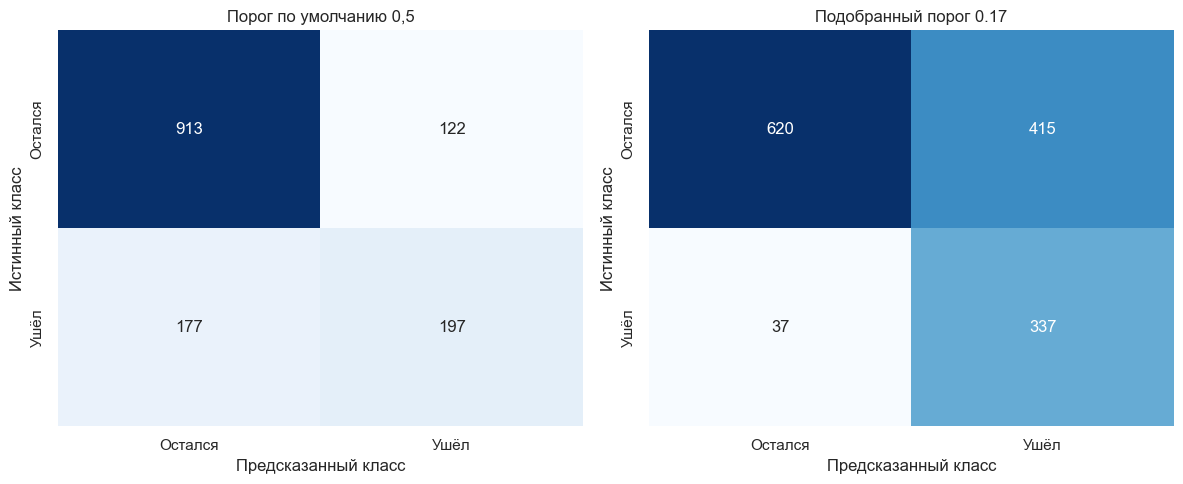

In [7]:
def evaluate_threshold(y_true, probabilities, threshold):
    pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'Порог': threshold,
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Стоимость': 5 * fn + fp
    }

comparison = pd.DataFrame([
    evaluate_threshold(y_test, y_test_proba, 0.5),
    evaluate_threshold(y_test, y_test_proba, best_threshold)
], index=['Порог по умолчанию', 'Подобранный порог'])
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, threshold, title in zip(
    axes, [0.5, best_threshold],
    ['Порог по умолчанию 0,5', f'Подобранный порог {best_threshold:.2f}']
):
    pred = (y_test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Остался', 'Ушёл'], yticklabels=['Остался', 'Ушёл'])
    ax.set(title=title, xlabel='Предсказанный класс', ylabel='Истинный класс')
plt.tight_layout()
plt.show()

In [8]:
default = comparison.loc['Порог по умолчанию']
selected = comparison.loc['Подобранный порог']
print(f'При пороге 0,5: precision={default.Precision:.3f}, recall={default.Recall:.3f}, F1={default.F1:.3f}, FN={int(default.FN)}, FP={int(default.FP)}, стоимость={int(default["Стоимость"])}.')
print(f'При пороге {best_threshold:.2f}: precision={selected.Precision:.3f}, recall={selected.Recall:.3f}, F1={selected.F1:.3f}, FN={int(selected.FN)}, FP={int(selected.FP)}, стоимость={int(selected["Стоимость"])}.')
print(f'ROC-AUC={roc_auc:.3f}, PR-AUC={pr_auc:.3f}.')

При пороге 0,5: precision=0.618, recall=0.527, F1=0.569, FN=177, FP=122, стоимость=1007.
При пороге 0.17: precision=0.448, recall=0.901, F1=0.599, FN=37, FP=415, стоимость=600.
ROC-AUC=0.832, PR-AUC=0.622.


## Вывод

Логистическая регрессия показала `ROC-AUC = 0,832`: модель достаточно хорошо ранжирует клиентов по риску ухода. `PR-AUC = 0,622`, что заметно выше базовой доли положительного класса 0,265. При пороге 0,5 получены `precision = 0,618`, `recall = 0,527`, `F1 = 0,569`, 177 FN и стоимость ошибок 1007. При цене `FN = 5` и `FP = 1` на validation выбран порог 0,17. На test он дал `precision = 0,448`, `recall = 0,901`, `F1 = 0,599`, сократил FN до 37 и стоимость до 600. Число FP выросло со 122 до 415, однако такой компромисс обоснован: пропуск уходящего клиента считается в пять раз дороже лишнего удерживающего предложения.